# Long-Horizon Emissions Forecasting for 2030 Target Assessment: A Comparative Study of N-HiTS, XGBoost, and Bayesian Models in Fast-Moving Consumer Goods Supply Chains
**Authors**: Idris Alugo 

**Paper**: *Applied Energy* (submitted 2026)  
**Zenodo DOI**: [to be assigned]

This notebook orchestrates the full pipeline:
1. Data loading & feature engineering  
2. Per-facility model training (N-HiTS, XGBoost-Quantile, BNN)  
3. Out-of-fold meta-feature construction  
4. Stacking ensemble (meta-learner) training  
5. 2030 forecast generation  
6. Risk & compliance assessment  
7. SHAP explainability  
8. Publication figures

All heavy logic lives in `src/` — this notebook is the **single entry point** to reproduce all results.


## 0. Environment

In [1]:
import sys, importlib
print(f"Python {sys.version}")

required = [
    "numpy", "pandas", "torch", "xgboost",
    "neuralforecast", "shap", "sklearn",
    "matplotlib", "seaborn", "scipy",
]
missing = []
for pkg in required:
    try:
        importlib.import_module(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← MISSING")

if missing:
    raise ImportError(f"Install missing packages: pip install {' '.join(missing)}")
else:
    print("\nAll dependencies satisfied.")


Python 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
  ✓ numpy
  ✓ pandas
  ✓ torch
  ✓ xgboost


C:\Users\Idris\Downloads\Applied Energy\emissions-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 16:27:37,313	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-04-25 16:27:37,686	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


  ✓ neuralforecast
  ✓ shap
  ✓ sklearn
  ✓ matplotlib
  ✓ seaborn
  ✓ scipy

All dependencies satisfied.


## 1. Imports & Logging

In [2]:
import logging
import warnings
import numpy as np
import pandas as pd

# src modules
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # adjust if running from notebooks/

from config import (
    DATA_PATH, TARGET_COL, TEST_MONTHS, RANDOM_SEED,
    BASELINE_YEAR, TARGET_REDUCTION_RATE, MIN_TRAIN_ROWS,
)
from src.preprocessing import (
    load_and_clean_data,
    create_global_features_with_hierarchy,
)
from src.models.nhits_model   import run_nhits, predict_nhits_2030, shap_nhits
from src.models.xgboost_model import run_xgboost_quantile, predict_xgboost_2030, shap_xgboost
from src.models.bnn_model     import run_bnn, mc_predict_bnn, shap_bnn
from src.models.meta_learner  import (
    build_meta_features, train_meta_learner,
    predict_ensemble, evaluate_meta_learner,
)
from src.evaluation import (
    prepare_facility_targets,
    compute_calibrated_probabilities,
    compute_stakeholder_metrics,
    compare_model_metrics,
    compute_regional_summary,
    aggregate_shap_records,
)
from src.visualization import plot_all

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("pipeline")
np.random.seed(RANDOM_SEED)
logger.info("Imports complete.")


16:27:38  INFO      pipeline — Imports complete.


## 2. Data Loading & Feature Engineering

In [3]:
# Load and clean raw data
df_raw = load_and_clean_data(DATA_PATH)
logger.info("Raw data: %s", df_raw.shape)

# Define base numeric features (before hierarchy/lag enrichment)
BASE_NUMERIC_FEATURES = [
    "Month", "Year", "DayOfYear",
    "Production", "Energy_MWh", "Waste_Kg",
    "Renewable_percent", "PolicyWeight",
]
region_cols = [c for c in df_raw.columns if c.startswith("Region_")]
base_features = BASE_NUMERIC_FEATURES + region_cols

# Create enhanced feature set (lags, rolling stats, hierarchy embeddings)
df, global_scalers, features = create_global_features_with_hierarchy(df_raw, base_features)

logger.info("Enhanced data: %s | Features: %d", df.shape, len(features))
logger.info("Facilities: %s", df["Facility"].nunique())
df.head(3)

16:27:38  INFO      src.preprocessing — Loaded 2057 rows from C:\Users\Idris\Downloads\Applied Energy\emissions-forecast\data\esgdata.csv
16:27:38  INFO      src.preprocessing — Removed 1156 rows (outlier facilities). Remaining: 901
16:27:38  INFO      src.preprocessing — Date filter [2016–2023]: 494 rows remain
16:27:38  INFO      src.preprocessing — Region dummies added: ['Region_R1', 'Region_R2', 'Region_R3', 'Region_R7']
16:27:38  INFO      pipeline — Raw data: (494, 18)
16:27:38  INFO      src.preprocessing — NOTE: Target Emissions_tCO2 kept in ORIGINAL scale (y-scaler fitted but not applied).
16:27:38  INFO      src.preprocessing — Feature engineering complete. Base: 12 | Lags: 8 | Hierarchy: 4 | Interactions: 2 | Rolling/Trend: 3 | Total: 29
16:27:38  INFO      pipeline — Enhanced data: (494, 35) | Features: 29
16:27:38  INFO      pipeline — Facilities: 21


,Date,Region,Facility,Energy_MWh,Emission_Factor,Production,Emissions_tCO2,Waste_Kg,Renewable_percent,Transport_Emissions,...,ProductionLag12,FacilityMeanEmission,FacilityStdEmission,RegionalMeanEmission,FacilityDeviationFromRegion,ProductionRegionInteraction,EnergyPolicyWeightInteraction,RegionRollingEmissions6M,RegionRollingEmissions12M,RegionalYearTrend
0,2022-01-01,R1,F10,-0.302112,EF,0.021273,40.50,-0.237649,0.0,0,...,-0.34173,38.200833,6.850016,97.722586,-59.521753,0.037611,-0.0,40.500,40.500,-18.581905
48,2022-01-01,R3,F12,-0.017081,EF,-0.300740,93.92,-0.045652,0.0,0,...,-0.34173,48.535833,24.631782,368.007500,-319.471667,-1.453238,-0.0,93.920,93.920,-28.997500
446,2022-01-01,R1,F7,0.305990,EF,1.827980,97.25,1.285872,0.0,0,...,-0.34173,47.852917,25.315644,97.722586,-49.869670,3.231845,0.0,68.875,68.875,-18.581905


## 2b. Facility Emissions Profile Clustering


-- Silhouette Scores --
  K=2  silhouette=0.6988
  K=3  silhouette=0.6484  <-- selected (elbow)
  K=4  silhouette=0.4541
  K=5  silhouette=0.4075
  K=6  silhouette=0.3694
  K=7  silhouette=0.3457
  K=8  silhouette=0.3400

-- Cluster Membership (K=3, manuscript-aligned) --
  High Emitter: 2 (10%)  mean=703.0 tCO2  -> F44, F43
  Medium Emitter: 8 (38%)  mean=114.2 tCO2  -> F27, F31, F22, F33, F18, F30, F28, F25
  Low Emitter: 11 (52%)  mean=18.2 tCO2  -> F4, F2, F13, F17, F9, F19, F6, F11, F10, F7, F12


17:44:11  INFO      src.visualization — Saved: ../figures\figure7_facility_clusters.png


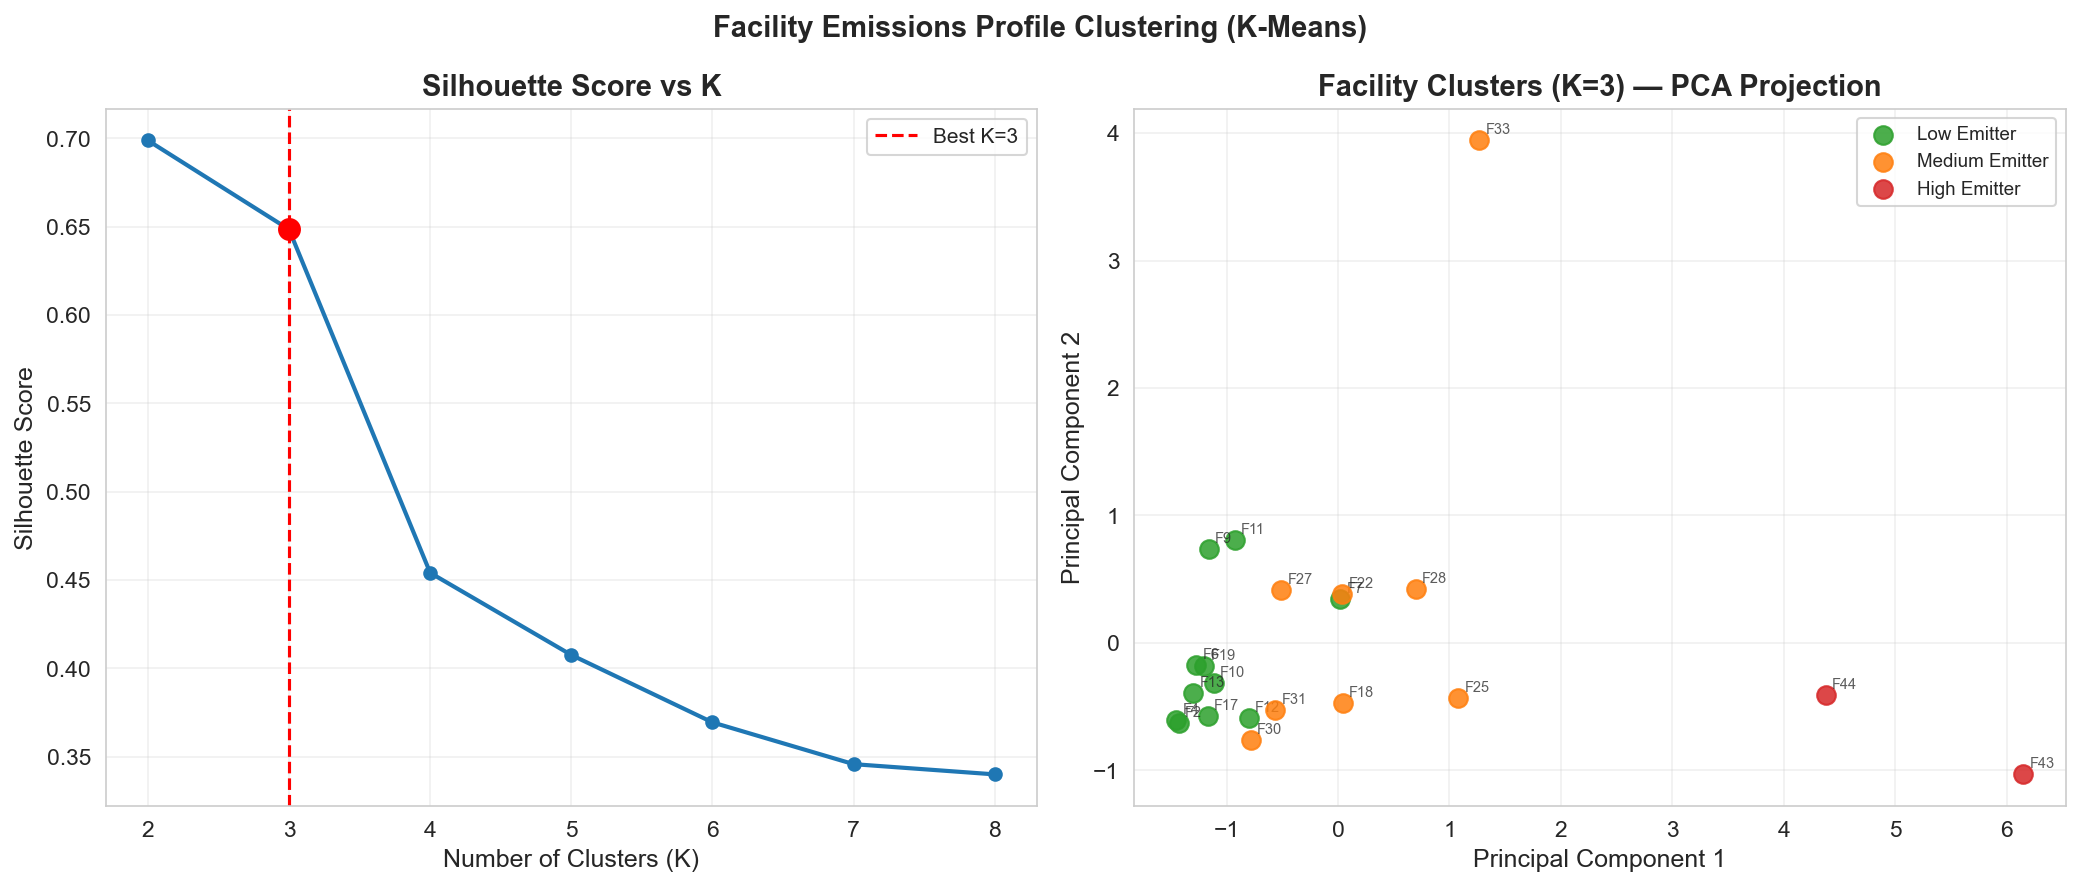


Saved: ../figures\figure7_facility_clusters.png


In [18]:
import os
from src.models.clustering_model import run_facility_clustering
from src.visualization import plot_facility_clusters

clust = run_facility_clustering(df_raw)

print("-- Silhouette Scores --")
for k, s in sorted(clust["sil_scores"].items()):
    marker = "  <-- selected (elbow)" if k == clust["best_k"] else ""
    print(f"  K={k}  silhouette={s:.4f}{marker}")

print("\n-- Cluster Membership (K=3, manuscript-aligned) --")
n_fac = len(clust["fac_df"])
for label, members in [
    ("High Emitter",   clust["high_facs"]),
    ("Medium Emitter", clust["medium_facs"]),
    ("Low Emitter",    clust["low_facs"]),
]:
    pct    = round(len(members) / n_fac * 100)
    mean_e = clust["fac_df"].loc[members, "MeanEmissions"].mean()
    print(f"  {label}: {len(members)} ({pct}%)  mean={mean_e:.1f} tCO2  -> {', '.join(members)}")

os.makedirs("../figures", exist_ok=True)
cluster_fig_path = plot_facility_clusters(
    clust["cluster_df"], clust["sil_scores"], clust["best_k"],
    output_dir="../figures", show=True,
)
print(f"\nSaved: {cluster_fig_path}")


## 3. Per-Facility Model Training

> Trains N-HiTS, XGBoost-Quantile, and BNN for each facility. Collects OOF predictions for meta-learning.

In [5]:
from sklearn.model_selection import TimeSeriesSplit

results          = []
meta_feature_records = []
shap_records     = []
bnn_res_dict     = {}
xgb_res_dict     = {}
nhits_res_dict   = {}

tscv = TimeSeriesSplit(n_splits=3)

for fac in df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].sort_values("Date").reset_index(drop=True)
    logger.info("=" * 60)
    logger.info("Facility: %s  (%d rows)", fac, len(df_fac))

    if len(df_fac) < MIN_TRAIN_ROWS or df_fac[TARGET_COL].nunique() < 2:
        logger.warning("Skipping %s — insufficient data or no target variance.", fac)
        continue

    nhits_oof = np.full(len(df_fac), np.nan)
    xgb_oof   = np.full(len(df_fac), np.nan)
    bnn_oof   = np.full(len(df_fac), np.nan)

    # ── Out-of-fold predictions (TimeSeriesSplit) ──────────────────────────
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(df_fac)):
        df_train = df_fac.iloc[train_idx]
        df_test  = df_fac.iloc[test_idx]
        n_test   = len(df_test)

        # N-HiTS OOF
        try:
            res = run_nhits(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("model") is not None:
                for i, idx in enumerate(test_idx):
                    if i < len(res["y_pred"]):
                        nhits_oof[idx] = res["y_pred"][i]
        except Exception as e:
            logger.debug("N-HiTS OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # XGBoost OOF
        try:
            res = run_xgboost_quantile(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test,
            )
            if res and res.get("models") and 0.5 in res["models"]:
                preds = res["models"][0.5].predict(df_test[features].values)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        xgb_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("XGBoost OOF fold %d failed for %s: %s", fold_idx, fac, e)

        # BNN OOF
        try:
            res = run_bnn(
                pd.concat([df_train, df_test], ignore_index=True),
                fac, features, TARGET_COL, test_months=n_test, n_epochs=100,
            )
            if res and res.get("model") is not None:
                mc = mc_predict_bnn(res["model"], df_test[features].values)
                preds = mc.mean(axis=0)
                for i, idx in enumerate(test_idx):
                    if i < len(preds):
                        bnn_oof[idx] = preds[i]
        except Exception as e:
            logger.debug("BNN OOF fold %d failed for %s: %s", fold_idx, fac, e)

    # ── Final models trained on full facility data ─────────────────────────
    nhits_res = run_nhits(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    xgb_res   = run_xgboost_quantile(df_fac, fac, features, TARGET_COL, TEST_MONTHS)
    bnn_res   = run_bnn(df_fac, fac, features, TARGET_COL, TEST_MONTHS, n_epochs=300)

    nhits_res_dict[fac] = nhits_res
    xgb_res_dict[fac]   = xgb_res
    bnn_res_dict[fac]   = bnn_res

    results.append({
        "Facility":    fac,
        "NHITSMAPE":   nhits_res.get("mape", np.nan),
        "NHITSRMSE":   nhits_res.get("rmse", np.nan),
        "XGBoostMAPE": xgb_res.get("mape", np.nan),
        "XGBoostRMSE": xgb_res.get("rmse", np.nan),
        "BNNMAPE":     bnn_res.get("mape", np.nan),
        "BNNRMSE":     bnn_res.get("rmse", np.nan),
    })

    # ── Collect OOF meta-feature rows ─────────────────────────────────────
    for i in range(len(df_fac)):
        has_nhits = not np.isnan(nhits_oof[i])
        has_xgb   = not np.isnan(xgb_oof[i])
        has_bnn   = not np.isnan(bnn_oof[i])
        if has_nhits or has_xgb or has_bnn:
            meta_feature_records.append({
                "Facility": fac,
                "NHITS_OOF": nhits_oof[i] if has_nhits else 0.0,
                "XGB_OOF":   xgb_oof[i]   if has_xgb   else 0.0,
                "BNN_OOF":   bnn_oof[i]   if has_bnn   else 0.0,
                "y_true":    df_fac.iloc[i][TARGET_COL],
            })

    # ── SHAP analysis ──────────────────────────────────────────────────────
    X_val = df_fac[features].values[-TEST_MONTHS:]
    X_train_shap = df_fac[features].values[:-TEST_MONTHS]

    mean_abs_xgb = mean_abs_bnn = mean_abs_nhits = None

    if xgb_res and xgb_res.get("models") and 0.5 in xgb_res["models"]:
        try:
            sv = shap_xgboost(xgb_res["models"][0.5], X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_xgb = np.abs(sv).mean(axis=0)
        except Exception as e:
            logger.debug("XGB SHAP failed for %s: %s", fac, e)

    if bnn_res and bnn_res.get("model") is not None:
        try:
            sv = shap_bnn(bnn_res["model"], X_train_shap, X_val, features, fac, show_plot=False)
            if sv is not None:
                mean_abs_bnn = np.abs(sv).mean(axis=0)
        except Exception as e:
            logger.debug("BNN SHAP failed for %s: %s", fac, e)

    try:
        sv = shap_nhits(X_train_shap, X_val, features, fac, show_plot=False)
        if sv is not None:
            mean_abs_nhits = np.abs(sv).mean(axis=0)
    except Exception as e:
        logger.debug("N-HiTS SHAP failed for %s: %s", fac, e)

    if any(x is not None for x in [mean_abs_xgb, mean_abs_bnn, mean_abs_nhits]):
        zeros = np.zeros(len(features))
        for i, feat in enumerate(features):
            shap_records.append({
                "Facility":        fac,
                "Feature":         feat,
                "MeanAbsSHAPNHITS": mean_abs_nhits[i] if mean_abs_nhits is not None else zeros[i],
                "MeanAbsSHAPXGB":   mean_abs_xgb[i] if mean_abs_xgb is not None else zeros[i],
                "MeanAbsSHAPBNN":   mean_abs_bnn[i] if mean_abs_bnn is not None else zeros[i],
            })

results_df = pd.DataFrame(results)
logger.info("Training complete. %d facilities.", len(results_df))
results_df[["Facility","NHITSMAPE","XGBoostMAPE","BNNMAPE"]]

16:27:41  INFO      pipeline — ============================================================
16:27:41  INFO      pipeline — Facility: F10  (24 rows)
16:27:41  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (12 rows).
16:27:41  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (12 rows).
16:27:41  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (12 rows).
16:27:41  WARNING   src.models.nhits_model — N-HiTS: insufficient data for F10 (18 rows).
16:27:41  WARNING   src.models.xgboost_model — XGBoost: insufficient data for F10 (18 rows).
16:27:41  WARNING   src.models.bnn_model — BNN: insufficient data for F10 (18 rows).
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platfo

Epoch 99: 100%|█| 1/1 [00:00<00:00, 13.80it/s, v_num=1767, train_loss_step=0.95
Validation: |                                            | 0/? [00:00<?, ?it/s]
Validation: |                                            | 0/? [00:00<?, ?it/s]
Validation DataLoader 0: 100%|██████████████████| 1/1 [00:00<00:00, 362.99it/s]
Epoch 149: 100%|█| 1/1 [00:00<00:00, 13.72it/s, v_num=1767, train_loss_step=0.5

`Trainer.fit` stopped: `max_steps=150` reached.


Epoch 149: 100%|█| 1/1 [00:00<00:00, 13.31it/s, v_num=1767, train_loss_step=0.5

GPU available: False, used: False


...

Epoch 149: 100%|█| 1/1 [00:00<00:00,  9.88it/s, v_num=1845, train_loss_step=0.6

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████████████| 1/1 [00:00<00:00, 255.91it/s]


16:37:52  INFO      src.models.nhits_model — N-HiTS [F28] MAPE=43.85%  RMSE=49.3854  input_size=6
16:37:52  INFO      src.models.xgboost_model — XGBoost [F28] MAPE=20.07%  RMSE=24.1042
16:37:53  INFO      src.models.bnn_model — BNN [F28] MAPE=96.60%  RMSE=110.3773  val_loss=12345.062500
16:37:53  WARNING   src.models.xgboost_model — XGBoost SHAP failed for F28 (could not convert string to float: '[1.4579001E2]'). Trying native pred_contribs fallback.
16:37:53  INFO      src.models.xgboost_model — XGBoost fallback contributions computed for F28  shape=(12, 29)
  0%|          | 0/12 [00:00<?, ?it/s]16:37:54  INFO      shap — num_full_subsets = 0
16:37:54  INFO      shap — remaining_weight_vector = array([0.31428133, 0.16761671, 0.11972622, 0.09670195, 0.08380835,
       0.07618941, 0.07183573, 0.0698403 ])
16:37:54  INFO      shap — num_paired_subset_sizes = 8
16:37:54  INFO      shap — weight_left = 0.9999999999999999
16:37:54  INFO      shap — np.sum(w_aug) = 16.999999999999996
16:37:5

,Facility,NHITSMAPE,XGBoostMAPE,BNNMAPE
0,F10,25.143458,15.166159,98.193542
1,F12,73.481225,40.286569,97.236646
2,F7,38.215125,61.187911,90.405955
3,F13,83.202053,19.036596,22.700414
4,F17,58.019370,12.357999,34.389733
5,F6,17.977866,20.310316,21.198183
6,F18,77.063382,20.338637,98.554315
7,F44,24.032028,14.353660,98.144506
8,F9,140.333683,42.166108,43.587784
9,F19,21.553127,36.168530,19.661741


## 4. Meta-Learner Ensemble Training

In [6]:
import pandas as pd

if "meta_feature_records" not in globals():
    raise RuntimeError("Run Cell 8 (Per-Facility Model Training) before this cell.")

meta_df = pd.DataFrame(meta_feature_records)
logger.info("Meta-feature rows collected: %d", len(meta_df))

# Augment with uncertainty & agreement features
meta_df_enhanced = build_meta_features(meta_df, bnn_res_dict, xgb_res_dict)

# Train stacking ensemble
meta_models, meta_feature_cols, meta_weights = train_meta_learner(
    meta_df_enhanced, verbose=True
)
logger.info("Meta-learner weights: %s", meta_weights)

# OOF evaluation
oof_eval = evaluate_meta_learner(
    meta_models, meta_weights, meta_feature_cols,
    meta_df_enhanced,
    individual_oof_cols={"N-HiTS": "NHITS_OOF", "XGBoost": "XGB_OOF", "BNN": "BNN_OOF"},
)
logger.info("Ensemble OOF MAPE=%.2f%%  RMSE=%.4f", oof_eval["ensemble_mape"], oof_eval["ensemble_rmse"])
pd.DataFrame([oof_eval]).T


16:37:54  INFO      pipeline — Meta-feature rows collected: 119
16:37:54  INFO      src.models.meta_learner — Meta-features built: 119 rows, 13 columns
16:37:54  INFO      src.models.meta_learner — Meta-learner training: 119 samples × 11 features
16:37:57  INFO      src.models.meta_learner —   ridge      CV-MSE=1415.945112  Weight=0.329
16:37:57  INFO      src.models.meta_learner —   elastic    CV-MSE=1352.453848  Weight=0.344
16:37:57  INFO      src.models.meta_learner —   gbm        CV-MSE=1954.802997  Weight=0.238
16:37:57  INFO      src.models.meta_learner —   rf         CV-MSE=5281.658805  Weight=0.088
16:37:57  INFO      pipeline — Meta-learner weights: {'ridge': 0.32901511693944574, 'elastic': 0.3444608090626722, 'gbm': 0.23831933306776026, 'rf': 0.08820474093012187}
16:38:01  INFO      src.models.meta_learner — Ensemble OOF  MAPE=44.63%  RMSE=23.5909
16:38:01  INFO      src.models.meta_learner —   N-HiTS   MAPE=37.43%  Improvement vs ensemble: -7.20%
16:38:01  INFO      src.mod

,0
ensemble_mape,44.629123
ensemble_rmse,23.590895
individual_mapes,"{'N-HiTS': 37.42953310463859, 'XGBoost': 22.00..."
improvement,"{'N-HiTS': -7.199589466240866, 'XGBoost': -22...."


## 5. 2030 Forecast Generation

In [7]:
from src.preprocessing import prepare_2030_features

nhits_quantile_preds = {}
xgb_quantile_preds   = {}
bnn_mc_preds         = {}

for fac in results_df["Facility"].unique():
    df_fac = df[df["Facility"] == fac].copy()
    X_2030 = prepare_2030_features(df, fac, features, global_scalers, base_features)

    # N-HiTS
    nhits_res = nhits_res_dict.get(fac)
    if nhits_res and nhits_res.get("model") is not None:
        preds = predict_nhits_2030(nhits_res["model"], df_fac, fac, features)
        if preds:
            nhits_quantile_preds[fac] = preds

    # XGBoost
    xgb_res = xgb_res_dict.get(fac)
    if xgb_res and xgb_res.get("models"):
        preds = predict_xgboost_2030(xgb_res["models"], X_2030)
        if preds:
            xgb_quantile_preds[fac] = preds

    # BNN
    bnn_res = bnn_res_dict.get(fac)
    if bnn_res and bnn_res.get("model") is not None:
        samples = mc_predict_bnn(bnn_res["model"], X_2030)
        samples = np.clip(samples, 0, None)
        bnn_mc_preds[fac] = samples.flatten()

logger.info(
    "2030 forecasts: N-HiTS=%d  XGBoost=%d  BNN=%d",
    len(nhits_quantile_preds), len(xgb_quantile_preds), len(bnn_mc_preds),
)


Predicting DataLoader 0: 100%|██████████████████| 1/1 [00:00<00:00, 185.84it/s]

16:38:03  INFO      pipeline — 2030 forecasts: N-HiTS=20  XGBoost=20  BNN=20


## 6. Risk & Compliance Assessment

In [8]:
# Facility-level baselines and targets
facility_baseline = prepare_facility_targets(
    df_raw,
    baseline_year=BASELINE_YEAR,
    target_reduction=TARGET_REDUCTION_RATE,
)

# Per-facility compliance probabilities
risk_df = compute_calibrated_probabilities(
    facility_baseline,
    nhits_quantile_preds,
    xgb_quantile_preds,
    bnn_mc_preds,
    results_df,
    n_bootstrap=1000,
)

# Regional roll-up
regional_summary = compute_regional_summary(risk_df, facility_baseline)

# Model comparison
comparison_df = compare_model_metrics(results_df)

print("\n── Risk Distribution ──────────────────────────")
print(risk_df["RiskLevelEnsemble"].value_counts().to_string())
print("\n── Model Comparison ───────────────────────────")
print(comparison_df.to_string())


16:38:03  INFO      src.evaluation — Targets prepared: 21 facilities | baseline_year=2022 | reduction=10%
16:38:03  INFO      src.evaluation — Compliance probabilities computed for 21 facilities. Risk distribution:
RiskLevelEnsemble
Medium Risk    12
High Risk       4
Low Risk        4
Unknown         1
16:38:03  INFO      src.evaluation — Regional summary computed for 4 regions.
16:38:03  INFO      src.evaluation — Model comparison computed for 3 models.



── Risk Distribution ──────────────────────────
RiskLevelEnsemble
Medium Risk    12
High Risk       4
Low Risk        4
Unknown         1

── Model Comparison ───────────────────────────
         Mean MAPE (%)  Std MAPE (%)  Mean RMSE  Std RMSE  N Facilities
Model                                                                  
N-HiTS           53.40         47.21    47.5090   64.1418            20
XGBoost          22.69         14.13    19.4509   25.6281            20
BNN              66.08         34.91   110.0958  191.0116            20


## 7. SHAP Feature Importance

In [9]:
shap_summary = aggregate_shap_records(shap_records, features)

print("── Top 15 Features by Average SHAP Contribution ──")
print(
    shap_summary.head(15)[
        ["Feature", "NHITSContribution", "XGBContribution",
         "BNNContribution", "AvgContribution", "Cumulative"]
    ].to_string(index=False)
)


16:38:03  INFO      src.evaluation — SHAP aggregated: top-5=67.3%  top-10=96.2%  features for 80% coverage=7


── Top 15 Features by Average SHAP Contribution ──
                    Feature  NHITSContribution  XGBContribution  BNNContribution  AvgContribution  Cumulative
             EmissionsLag12          38.812257         0.000000        20.994999        19.935752   19.935752
              EmissionsLag6          20.089483         1.376534        27.859837        16.441951   36.377703
   RegionRollingEmissions6M          14.471358         5.644995        11.256846        10.457733   46.835436
                 Production           0.023901        30.850910         0.420688        10.431833   57.267269
                 Energy_MWh           0.019839        29.903587         0.302949        10.075458   67.342728
  RegionRollingEmissions12M           9.585807         1.542563        17.719224         9.615865   76.958592
              EmissionsLag3          10.022438         2.604182        10.473668         7.700096   84.658688
              EmissionsLag1           5.988566         1.739831      

## 8. Publication Figures

16:38:04  INFO      src.visualization — Saved: ../figures\figure0_stakeholder_dashboard.png


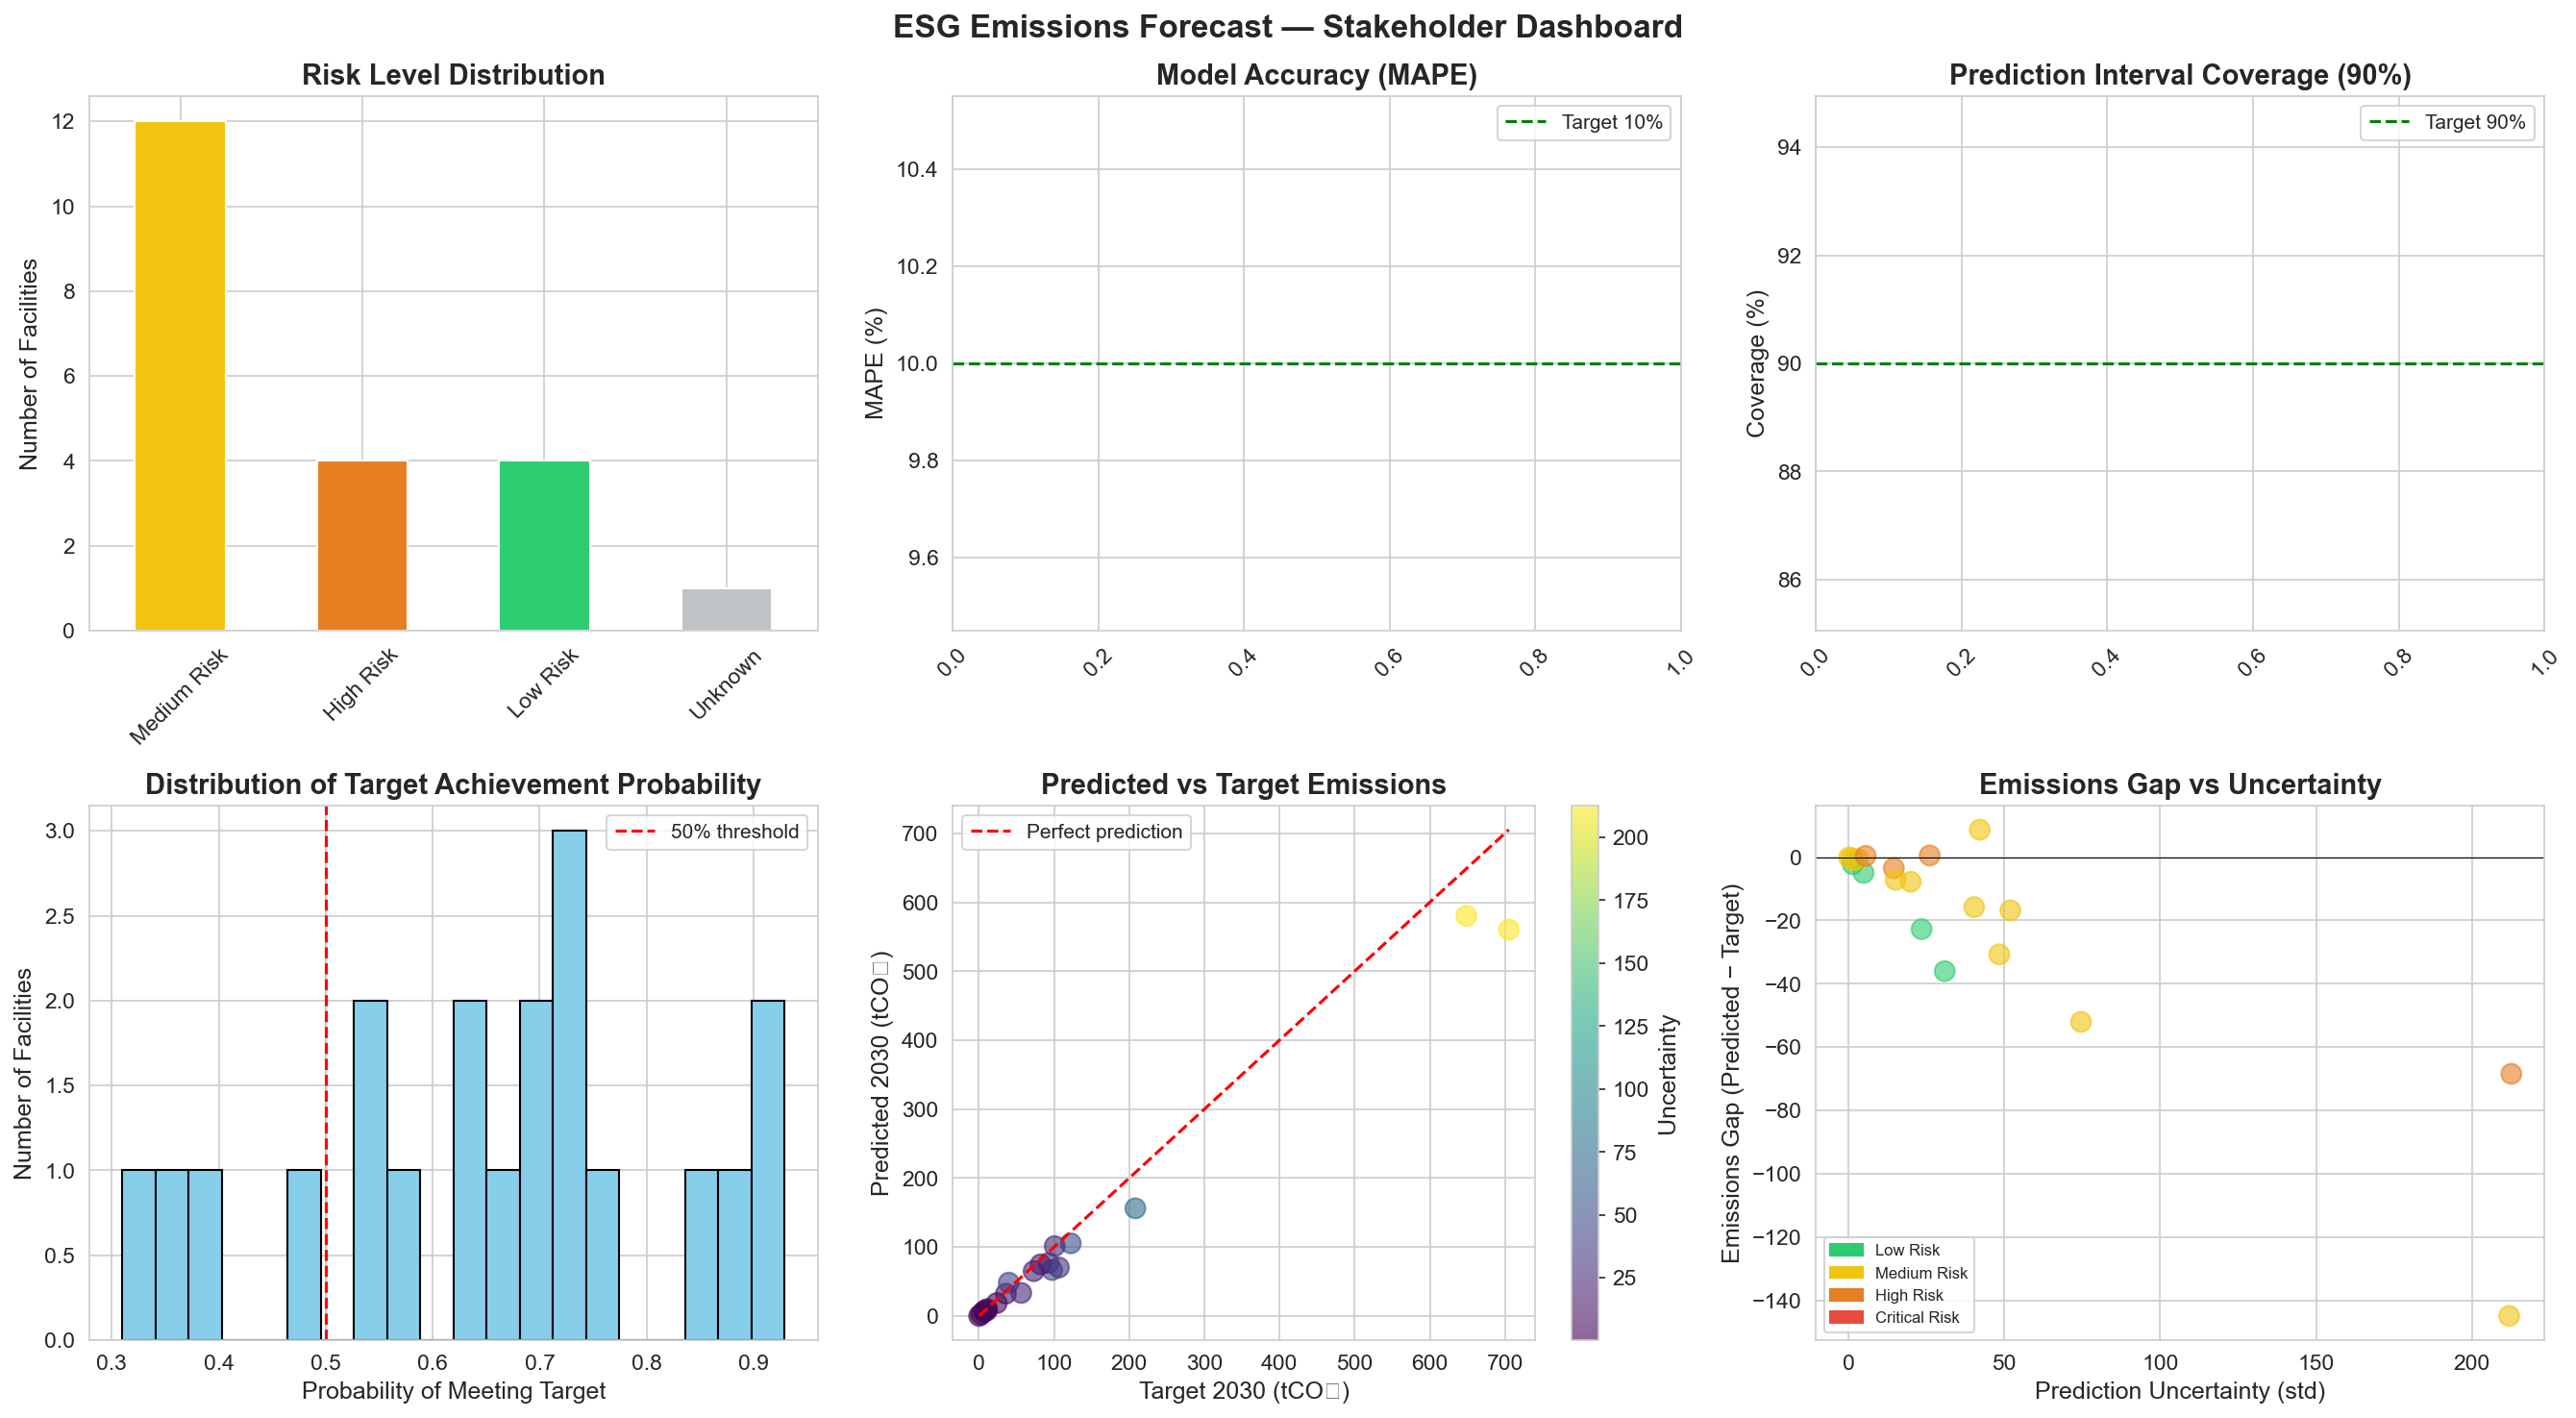

16:38:04  INFO      src.visualization — Saved: ../figures\figure1_mape_boxplot.png


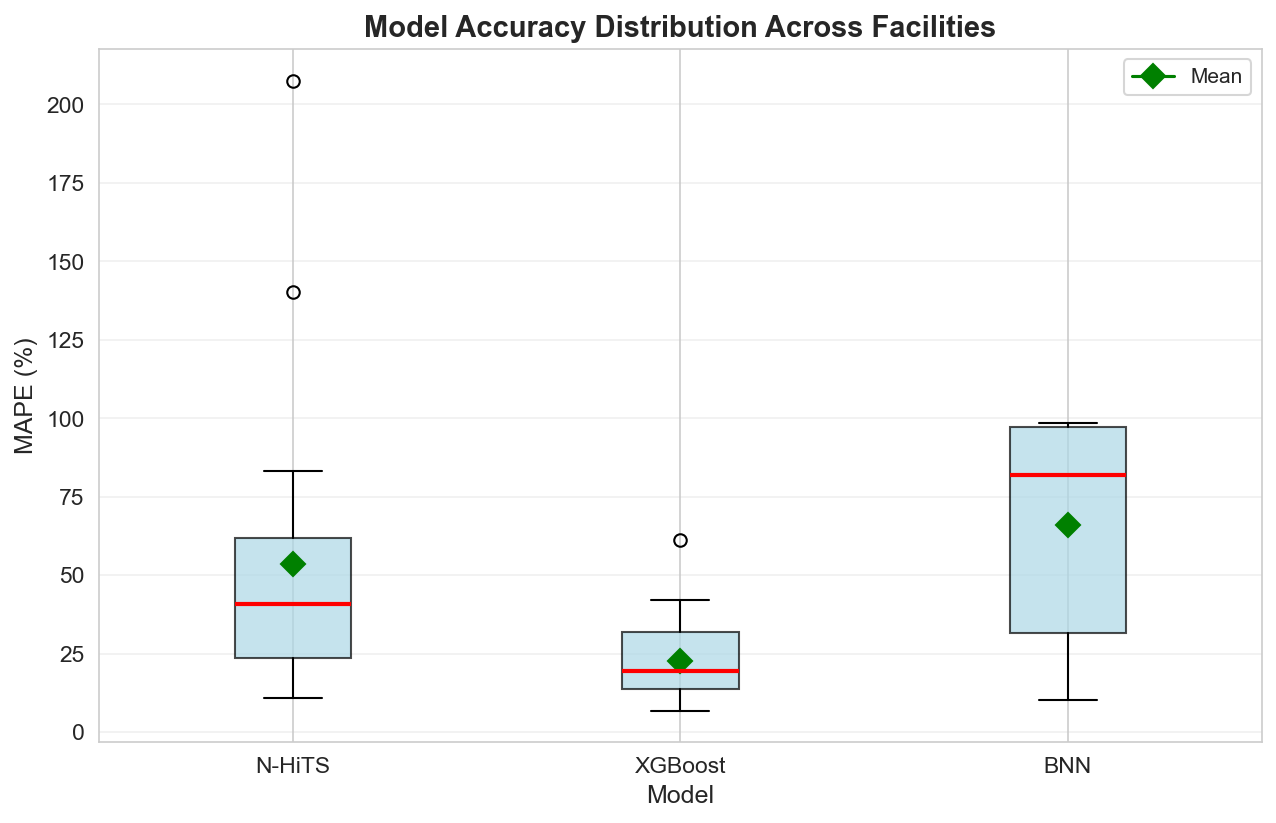

16:38:05  INFO      src.visualization — Saved: ../figures\figure2_uncertainty_decomposition.png


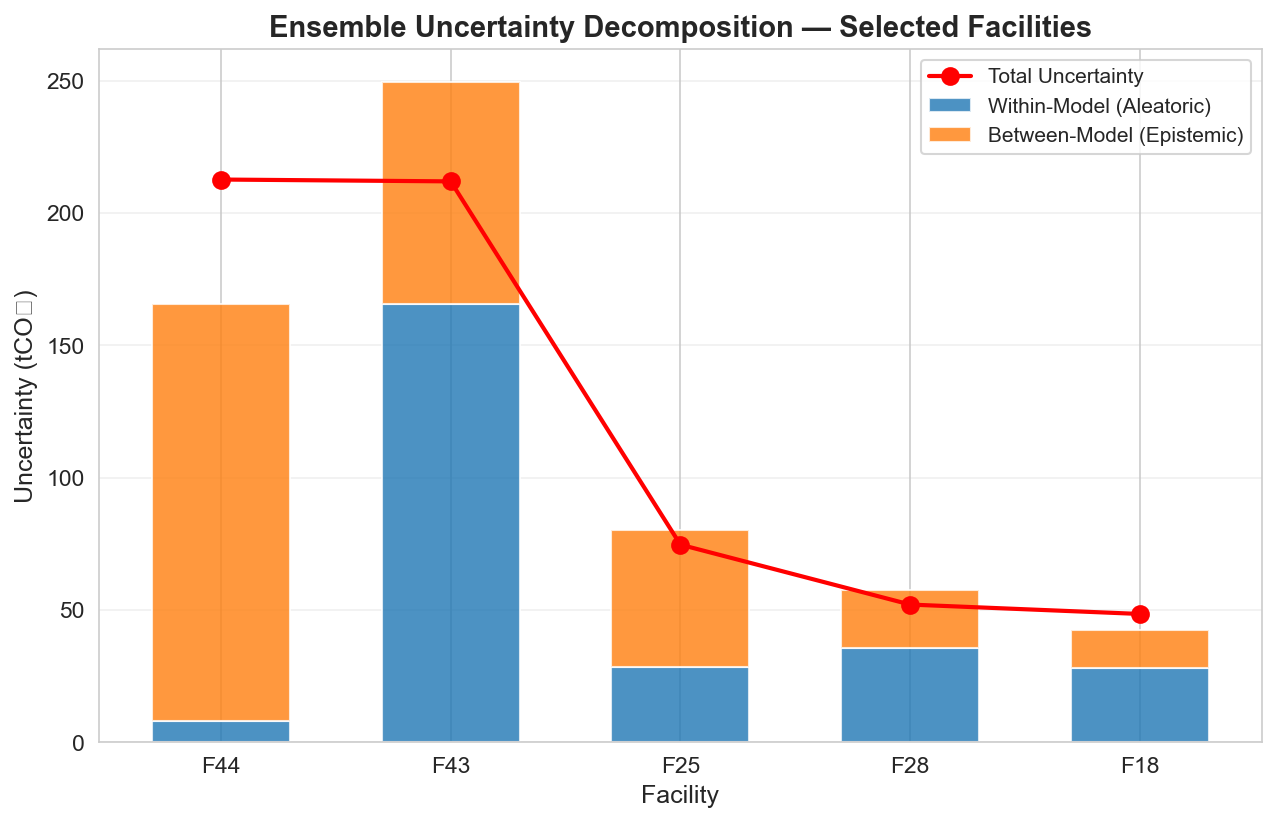

16:38:05  INFO      src.visualization — Saved: ../figures\figure3_shap_comparison.png


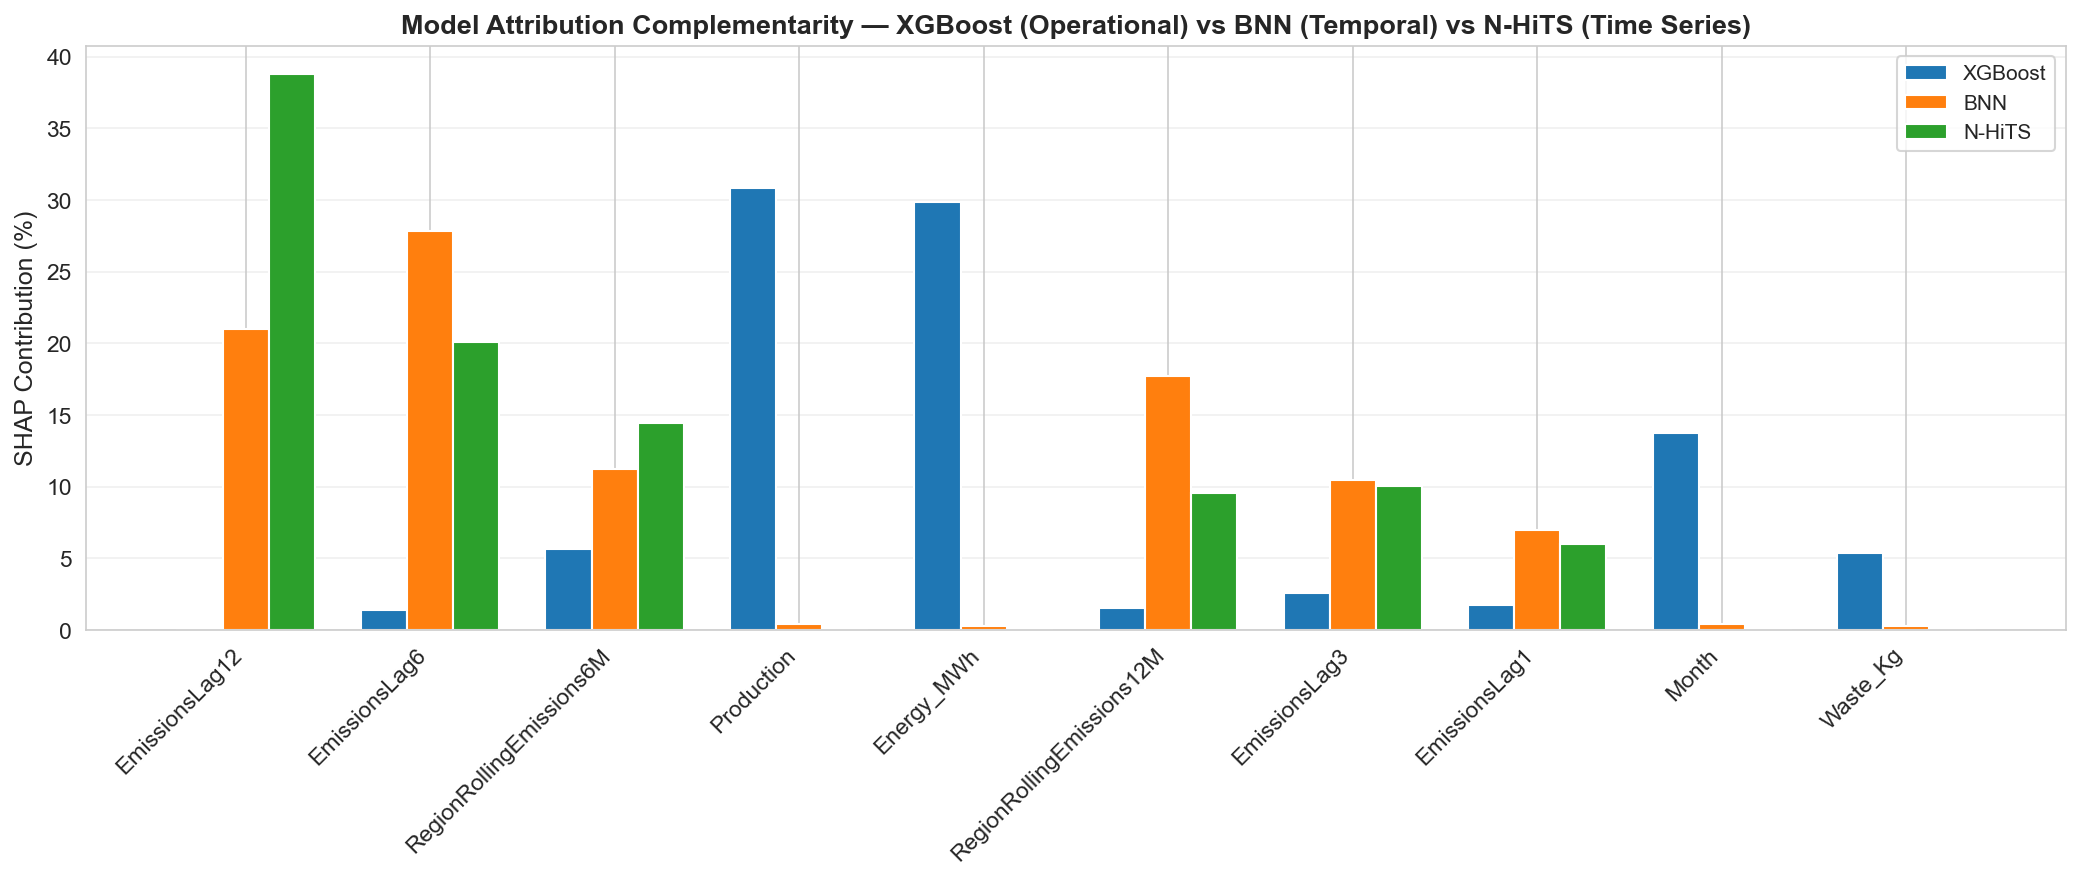

16:38:06  INFO      src.visualization — Saved: ../figures\figure4_probability_distribution.png


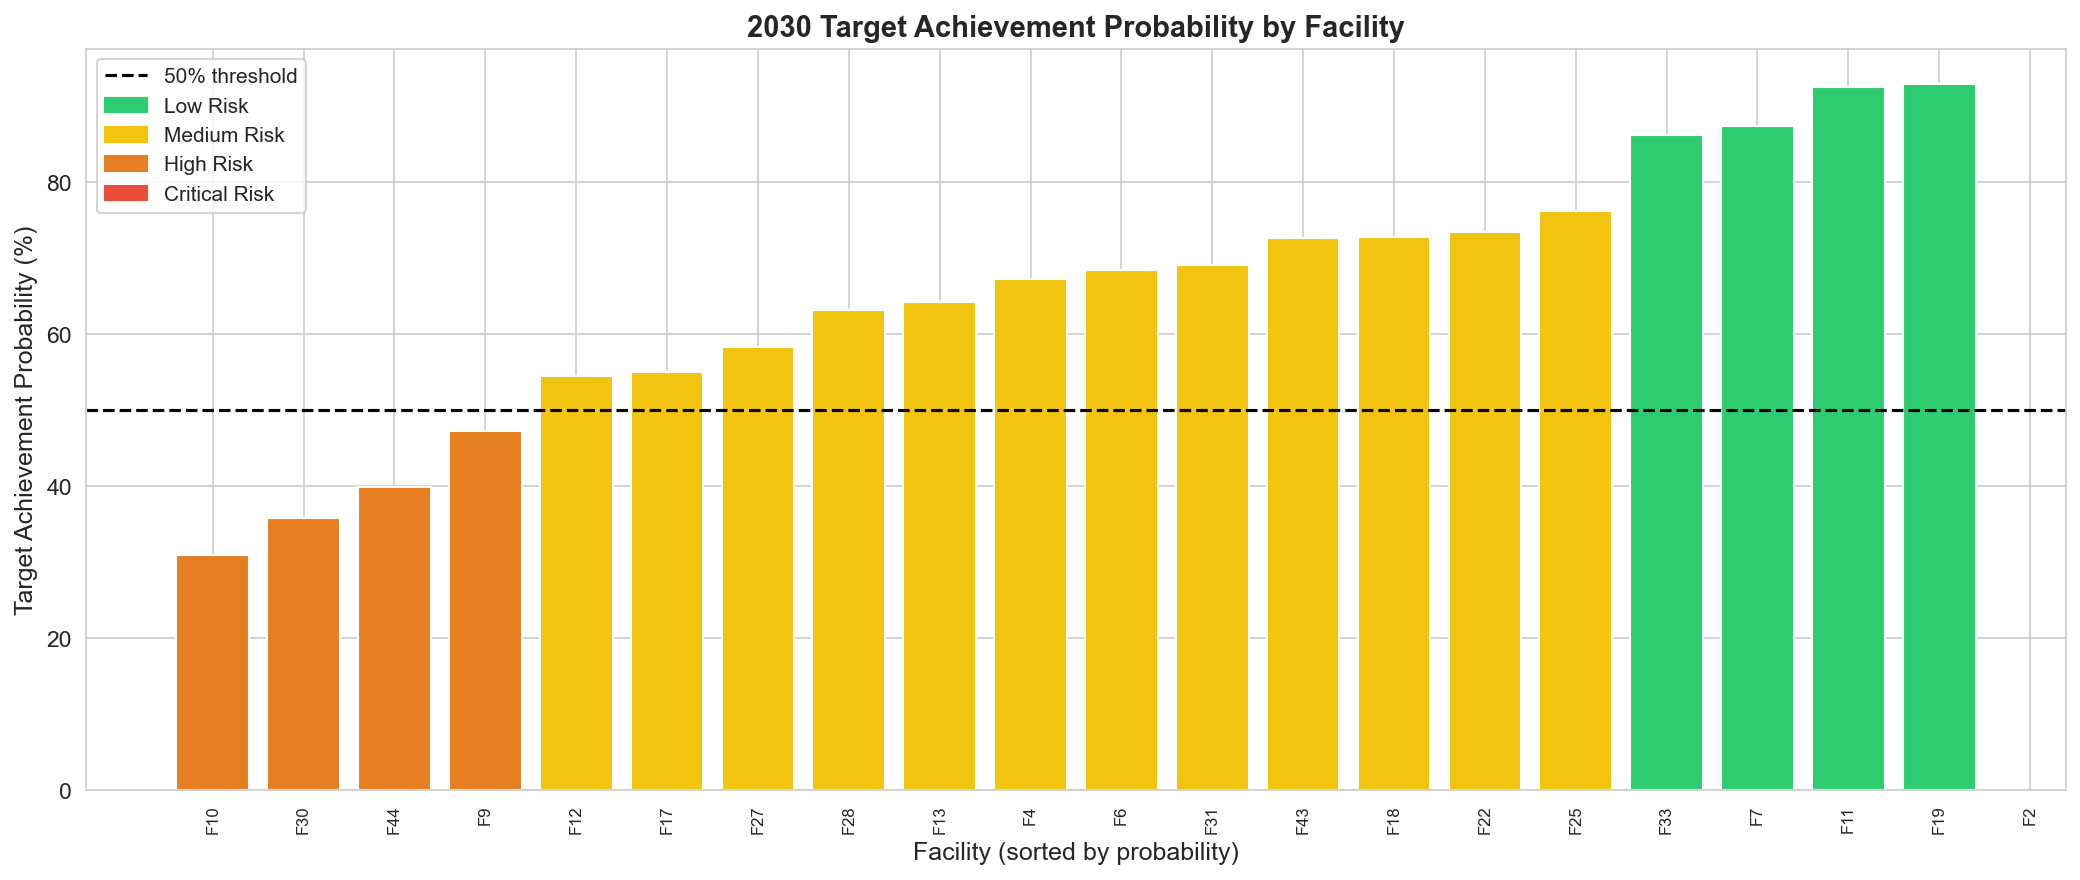

16:38:06  INFO      src.visualization — Saved: ../figures\figure5_model_agreement.png


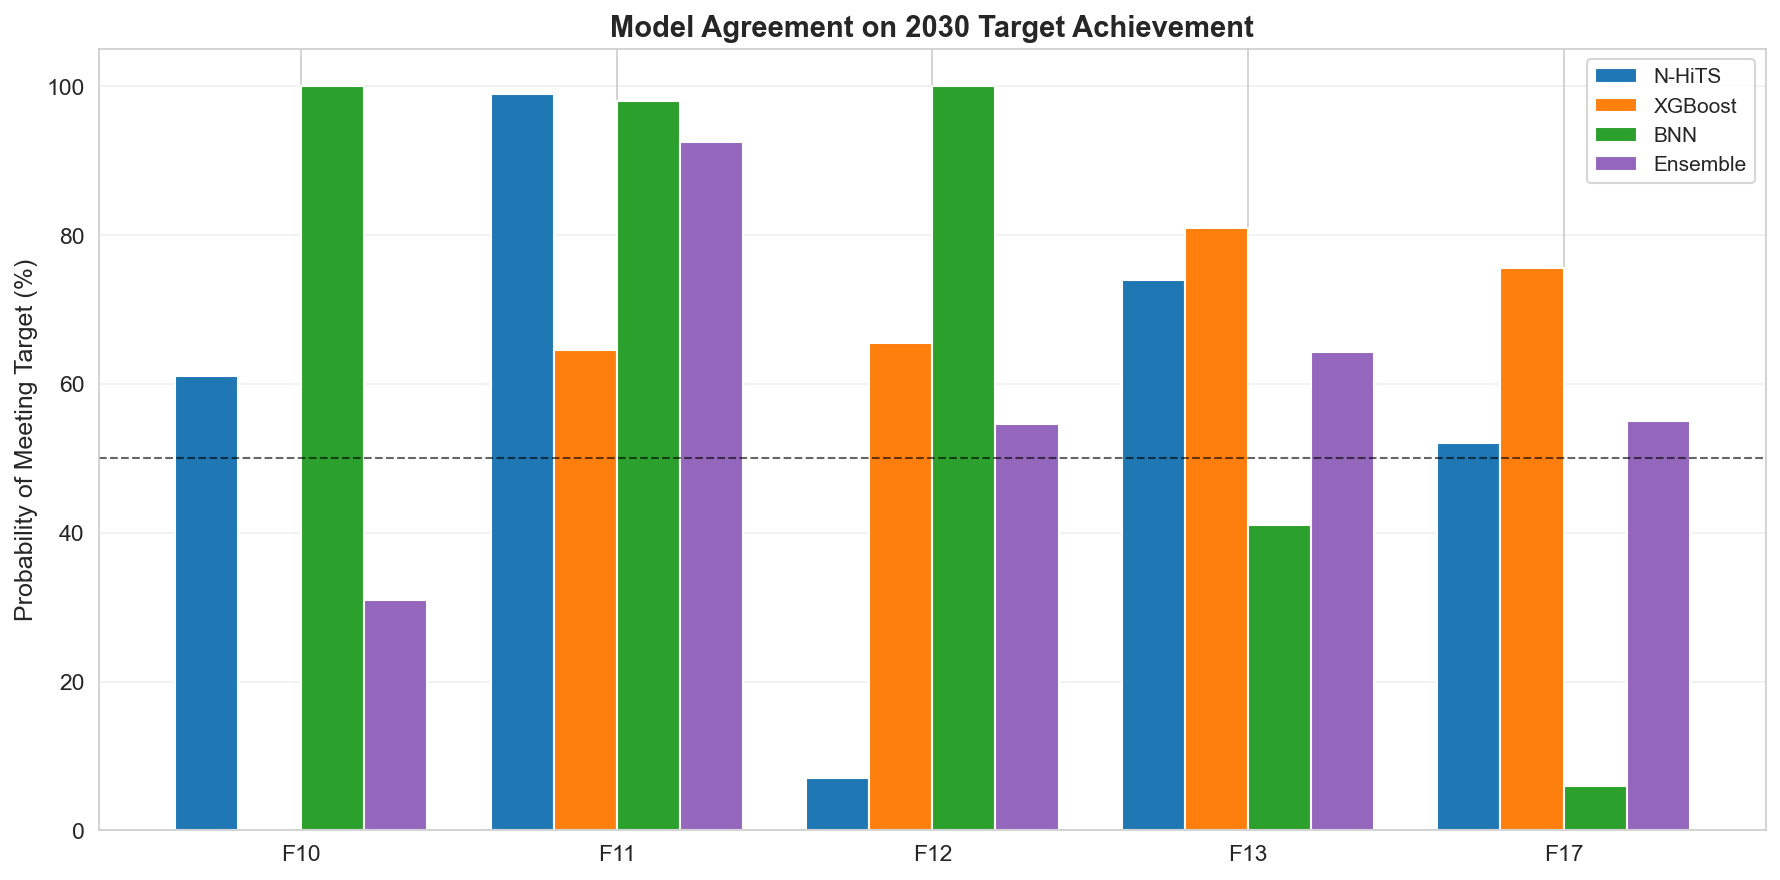

16:38:06  INFO      src.visualization — Saved: ../figures\figure6_facility_accuracy.png


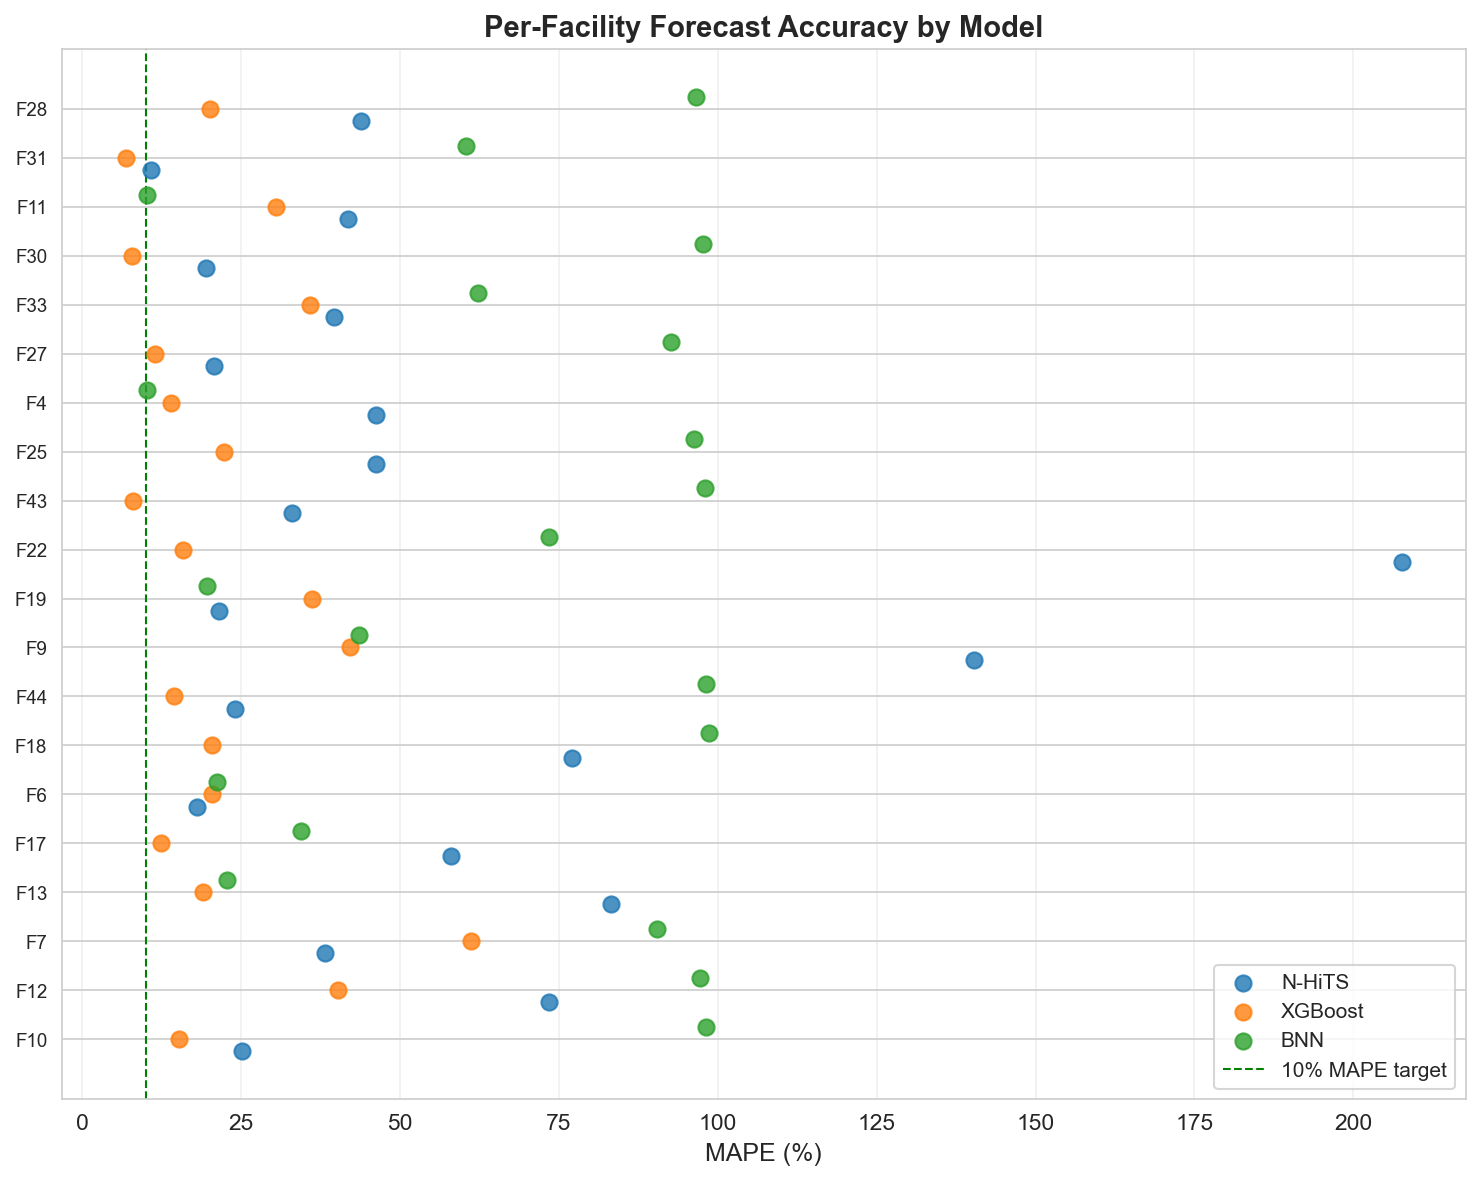

16:38:07  INFO      src.visualization — All figures saved to ../figures


Saved: ../figures\figure0_stakeholder_dashboard.png
Saved: ../figures\figure1_mape_boxplot.png
Saved: ../figures\figure2_uncertainty_decomposition.png
Saved: ../figures\figure3_shap_comparison.png
Saved: ../figures\figure4_probability_distribution.png
Saved: ../figures\figure5_model_agreement.png
Saved: ../figures\figure6_facility_accuracy.png


In [10]:
saved_paths = plot_all(
    results_df    = results_df,
    risk_df       = risk_df,
    comparison_df = comparison_df,
    shap_summary  = shap_summary,
    output_dir    = "../figures",
    show          = True,          # set False for headless runs
)
for p in saved_paths:
    print("Saved:", p)


## 9. Export Results

In [11]:
os.makedirs("../results", exist_ok=True)

results_df.to_csv("../results/model_accuracy.csv",      index=False)
risk_df.to_csv("../results/risk_assessment.csv",         index=False)
regional_summary.to_csv("../results/regional_summary.csv", index=False)
comparison_df.to_csv("../results/model_comparison.csv")

if len(shap_summary) > 0:
    shap_summary.to_csv("../results/shap_summary.csv", index=False)

logger.info("All results exported to ../results/")
print("Done. Results written to ../results/")


16:38:07  INFO      pipeline — All results exported to ../results/


Done. Results written to ../results/
